<a href="https://colab.research.google.com/github/pavanthiriveedi7-rgb/Meachine_Learning_practice/blob/main/Practice_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# 1. Load the data
# https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists
df = pd.read_csv('/content/aug_test.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [5]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,508
relevent_experience,0
enrolled_university,31
education_level,52
major_discipline,312
experience,5
company_size,622


In [6]:
# 2. DATA CLEANING
# Fill missing categorical values with 'Unknown'
cols_to_fix = ['gender', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
for col in cols_to_fix:
    df[col] = df[col].fillna('Unknown')

In [7]:
cols_to_fix

['gender',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [8]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,Unknown,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,Unknown,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,Unknown,<1,Unknown,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [9]:
# 3. CATEGORICAL ENCODING
# Turn text columns into numbers using Label Encoding
le = LabelEncoder()
for col in cols_to_fix + ['relevent_experience']:
    df[col] = le.fit_transform(df[col].astype(str))

In [10]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,1,0,0,0,5,19,7,6,0,21
1,9858,city_103,0.920,0,0,3,0,5,15,8,5,0,98
2,31806,city_21,0.624,1,1,3,1,6,20,8,5,6,15
3,27385,city_13,0.827,1,0,3,2,5,2,0,5,0,39
4,27724,city_103,0.920,1,0,3,0,5,21,3,5,4,72


In [11]:
np.random.seed(42)
df['target'] = np.random.randint(0, 2, df.shape[0])

In [12]:
df['target']

,target
0,0
1,1
2,0
3,0
4,0
...,...
2124,1
2125,1
2126,0
2127,0


In [13]:
#  PREPARE FEATURES (X) AND TARGET (y)
# Drop IDs and names as they don't help the model
x = df.drop(['enrollee_id', 'city', 'target'], axis=1)
y = df['target']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
x_train.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
1380,0.910,1,0,3,2,5,21,7,5,3,56
480,0.847,0,0,3,0,5,15,1,5,0,99
929,0.843,1,0,3,0,5,3,5,5,3,4
1944,0.920,0,1,0,0,5,13,7,0,0,104
1788,0.920,1,0,3,3,5,19,1,1,0,79


In [16]:
x_train.kurtosis()

,0
city_development_index,-0.703261
gender,-0.561003
relevent_experience,-1.138018
enrolled_university,-0.723233
education_level,1.936916
major_discipline,8.254841
experience,-0.860392
company_size,-1.469530
company_type,3.736490
last_new_job,-0.984900


In [17]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
x_train

array([[ 0.67866927, -0.47135629, -0.63830872, ...,  0.12083338,
         0.47959208, -0.14586428],
       [ 0.17770436, -1.56349203, -0.63830872, ...,  0.12083338,
        -0.90315958,  0.57352524],
       [ 0.14589706, -0.47135629, -0.63830872, ...,  0.12083338,
         0.47959208, -1.0158237 ],
       ...,
       [ 0.75818751, -0.47135629,  1.56664005, ...,  0.12083338,
         1.86234374,  0.35603538],
       [-0.24374232, -0.47135629,  1.56664005, ...,  0.81839017,
         1.86234374,  0.15527552],
       [-0.18012773, -0.47135629, -0.63830872, ..., -2.66939376,
         0.01867486,  0.60698522]])

In [19]:
# TRAIN LOGISTIC REGRESSION
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
model.score(x_train, y_train)

0.5302407516147974

In [ ]:
model.score(x_test, y_test)

0.5117370892018779

In [ ]:
from sklearn.metrics import f1_score
y_pred = model.predict(x_test)
f1_score(y_test, y_pred)

0.425414364640884

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,

In [ ]:
accuracy_score(y_test, y_pred)

0.5117370892018779

In [ ]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1
0,141,75
1,133,77


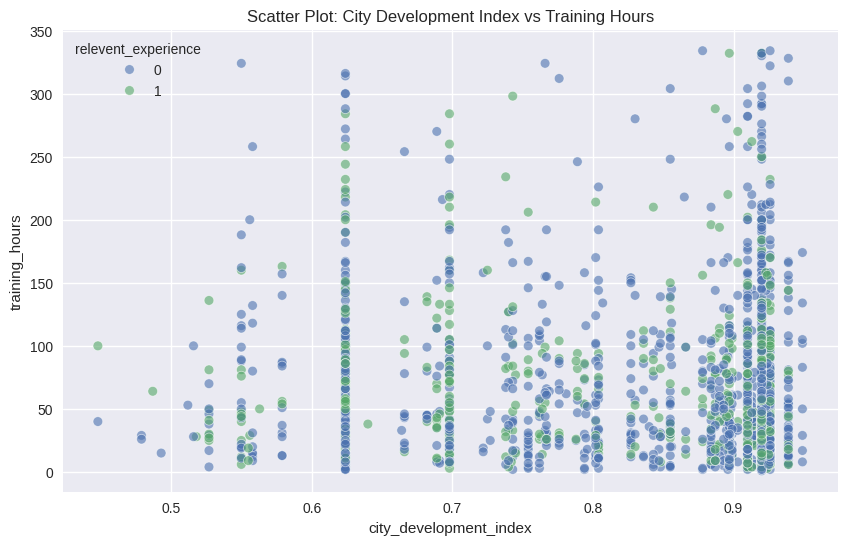

In [26]:
# Scatter Plot: City Development vs Training Hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='city_development_index', y='training_hours', hue='relevent_experience', alpha=0.6)
plt.title('Scatter Plot: City Development Index vs Training Hours')

Text(0.5, 1.0, 'Box Plot: City Development Index by Experience Type')

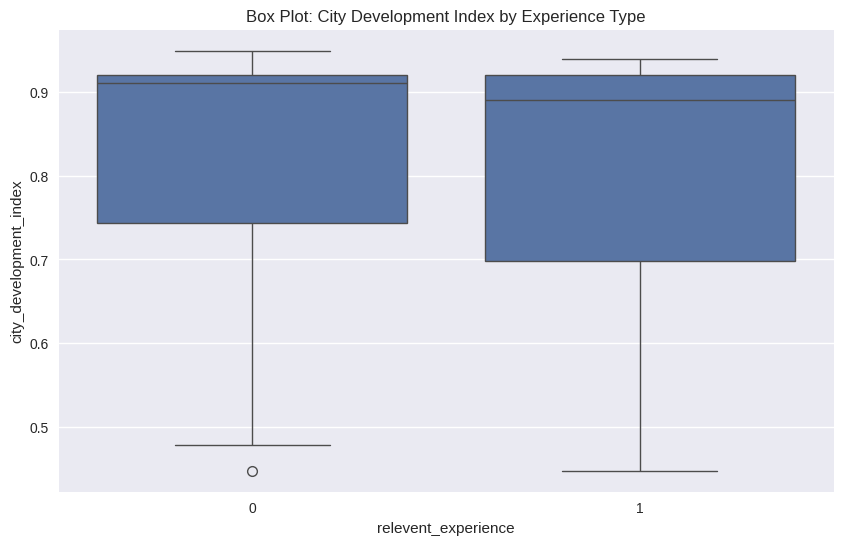

In [27]:
# Box Plot: City Development Index by Experience Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='relevent_experience', y='city_development_index')
plt.title('Box Plot: City Development Index by Experience Type')

Text(0.5, 1.0, 'Box Plot: Training Hours by Experience Type')

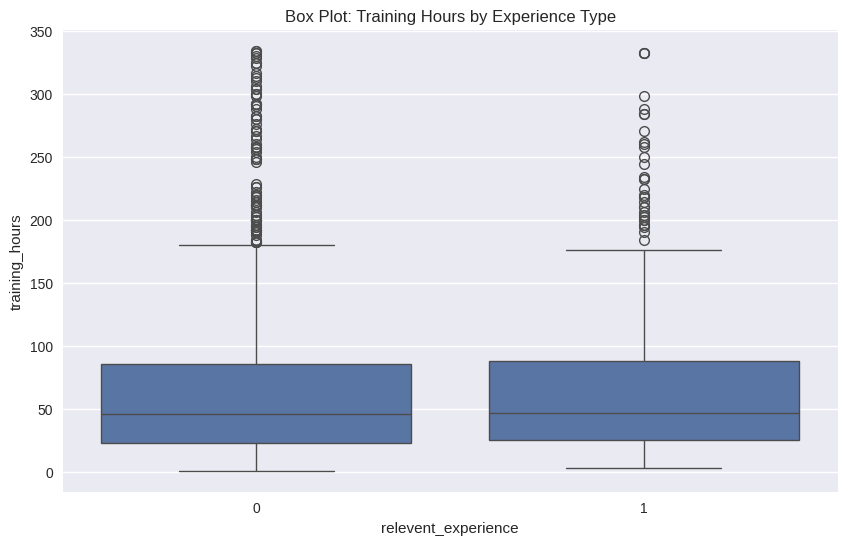

In [28]:
# Box Plot: Training Hours by Experience Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='relevent_experience', y='training_hours')
plt.title('Box Plot: Training Hours by Experience Type')